In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

## 1. Define Parameters

In [2]:
Qual_c = 4000 #quality factors
Qual_l = 40
w_c = jnp.sqrt(0.5) #computational and learning degrees of freedom
w_l = jnp.sqrt(1)
alpha_l = 0.1 #pumping strength
epsilon = 0.005 #duffing coefficient 

In [3]:
k_B = 1.0          # Boltzmann's constant (arbitrary units for simulation)
T = .2             # Temperature (K)
noise_strength_c =  jnp.sqrt(2*k_B*T*w_l/Qual_l)
noise_strength_l =  jnp.sqrt(2*k_B*T*w_c/Qual_c)  

In [4]:
mu_m = 0.005 #arbitrary
delta_t = 100 #arbitrary
mu_func = lambda t: mu_m * jnp.exp(-t**2/2*delta_t**2)

lambda_0 = 1 #completely arbitrary 
c_0 = 1 #completely arbitrary
lambda_func = lambda t: lambda_0

In [12]:
# Simulation Parameters
period = 2*jnp.pi/w_c #random
t0 = 0.0  
num_periods = 100 #2000# Start time
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)

# Initial Conditions
y0 = jnp.zeros(12)

## 2. Define SDE functions

In [13]:
def local_hamiltonian(x, y, s, mu_t):
    return mu_t * (x - y)**2 * s**2

def interacting_hamiltonian(x1, x2, y1, y2, s1, s2, lambda_t):
    return lambda_t * (c_0 + (s1 - s2)**2) * (x1*x2 + y1*y2)

def hamiltonian(x, y, s, mu_t, lambda_t, xo, yo, so):
    return local_hamiltonian(x, y, s, mu_t) + interacting_hamiltonian(x, xo, y, yo, s, so, lambda_t)

In [14]:
# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    
    x1, vx1, y1, vy1, s1, vs1, x2, vx2, y2, vy2, s2, vs2 = state
    
    mu_t = mu_func(t)
    lambda_t = mu_func(t)
    
    dx1 = vx1
    dvx1 = -w_c/Qual_c * vx1 - w_c**2 * x1 - jax.grad(lambda x: hamiltonian(x, y1, s1, mu_t, lambda_t, x2, y2, s2))(x1)
    dy1 = vy1
    dvy1 = -w_c/Qual_c * vy1 - w_c**2 * y1 - jax.grad(lambda y: hamiltonian(x1, y, s1, mu_t, lambda_t, x2, y2, s2))(y1)
    ds1 = vs1
    dvs1 = -w_l/Qual_l * vs1 - w_l**2 * (1 + alpha_l * jnp.sin(2 * w_l * t)) * s1 - epsilon * s1**3 - jax.grad(lambda s: hamiltonian(x1, y1, s, mu_t, lambda_t, x2, y2, s2))(s1)
    
    hamiltonian_2 = hamiltonian(x2, y2, s2, mu_t, lambda_t, x1, y1, s1)
    dx2 = vx2
    dvx2 = -w_c/Qual_c * vx2 - w_c**2 * x2 - jax.grad(lambda x: hamiltonian(x, y2, s2, mu_t, lambda_t, x1, y1, s1))(x2)
    dy2 = vy2
    dvy2 = -w_c/Qual_c * vy2 - w_c**2 * y2 - jax.grad(lambda y: hamiltonian(x2, y, s2, mu_t, lambda_t, x1, y1, s1))(y2)
    ds2 = vs2
    dvs2 = -w_l/Qual_l * vs2 - w_l**2 * (1 + alpha_l * jnp.sin(2 * w_l * t)) * s2 - epsilon * s2**3 - jax.grad(lambda s: hamiltonian(x2, y2, s, mu_t, lambda_t, x1, y1, s1))(s2)
    
    return jnp.array([dx1, dvx1, dy1, dvy1, ds1, dvs1, dx2, dvx2, dy2, dvy2, ds2, dvs2])

def diffusion_x_fn(t, state, args):
    """
    Diffusion 
    """

    noise_matrix = jnp.zeros((12, 12))
    noise_matrix = noise_matrix.at[1, 1].set(noise_strength_c)
    noise_matrix = noise_matrix.at[3, 3].set(noise_strength_c)
    noise_matrix = noise_matrix.at[5, 5].set(noise_strength_l)
    noise_matrix = noise_matrix.at[7, 7].set(noise_strength_c)
    noise_matrix = noise_matrix.at[9, 9].set(noise_strength_c)
    noise_matrix = noise_matrix.at[11, 11].set(noise_strength_l)
    return noise_matrix

## 3. Solve SDE

In [15]:
w_shape = (12,)  # state is (x1, p1)
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)
terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
saveat = diffrax.SaveAt(ts=ts_dim)


# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=100000000000,
    # stepsize_controller=PIDController(rtol=rtol, atol=atol),
)


100.00%|██████████| [00:29<00:00,  3.34%/s]


## 4.  Extract relative phases of hidden oscillators and envelope of output oscillator

In [16]:
from scipy.signal import hilbert
import numpy as np

x1 = solution_x.ys[:, 0]
x2 = solution_x.ys[:, 2]
x3 = solution_x.ys[:, 4]

# Extract phases using Hilbert transform
analytic_signal_x1 = hilbert(x1)
analytic_signal_x2 = hilbert(x2)
analytic_signal_x3 = hilbert(x3)

# Calculate phase difference between x₁ and x₂
phase_diff = np.angle(analytic_signal_x1) - np.angle(analytic_signal_x2)
# Wrap to [-π, π]
phase_diff = np.mod(phase_diff + np.pi, 2 * np.pi) - np.pi

# Calculate envelope of x₃
envelope = np.abs(analytic_signal_x3)



## 5. Plot results

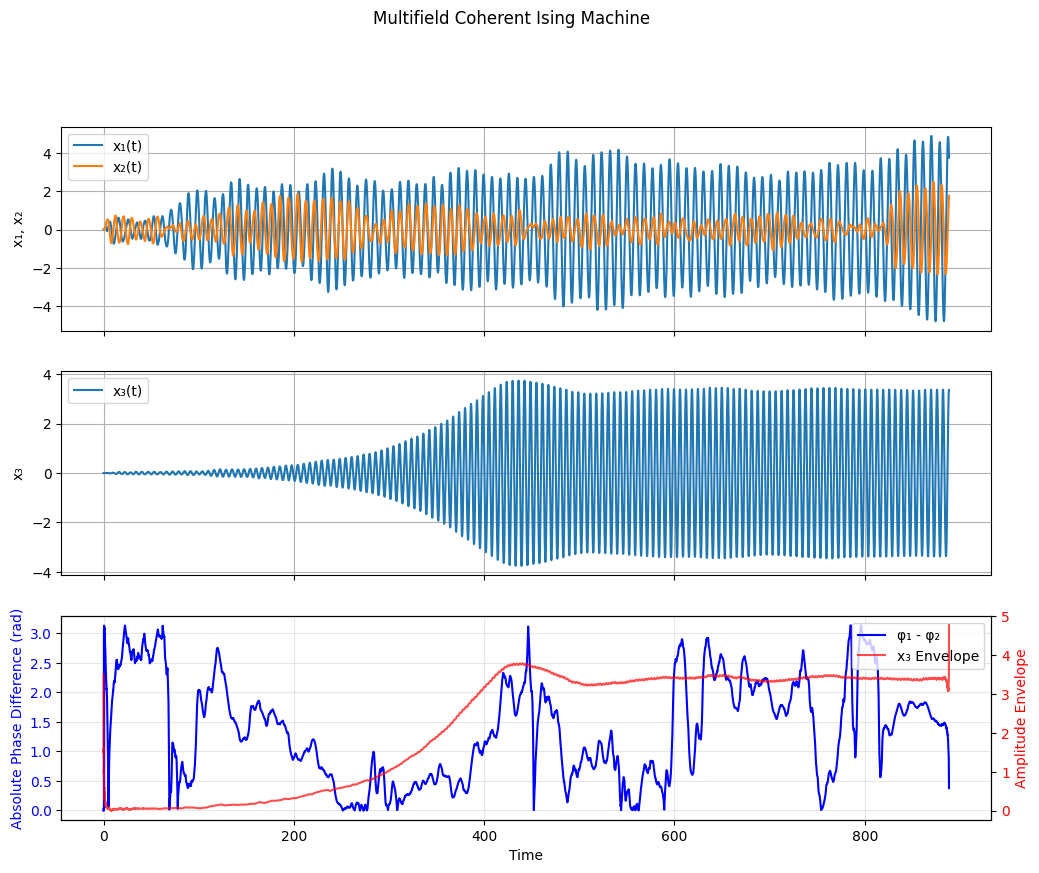

In [17]:
# Define start and end times as fractions of total time
start_frac = 0.0  # Start at beginning
end_frac = 1    # Show first 20%

# Calculate indices for the time window
start_idx = int(len(ts_dim) * start_frac)
end_idx = int(len(ts_dim) * end_frac)


# Create a 3x1 figure
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

title = ('Multifield Coherent Ising Machine')

# ... rest of plotting code ...
fig.suptitle(title, y=1.01)  # y=1.02 moves the title slightly above the figure

# First subplot: x1 and x2
ax1.plot(ts_dim[start_idx:end_idx], solution_x.ys[start_idx:end_idx, 0], label='x₁(t)')
ax1.plot(ts_dim[start_idx:end_idx], solution_x.ys[start_idx:end_idx, 2], label='x₂(t)')
ax1.set_ylabel('x₁, x₂')
ax1.grid(True)
ax1.legend()

# Second subplot: x3
ax2.plot(ts_dim[start_idx:end_idx], solution_x.ys[start_idx:end_idx, 4], label='x₃(t)')
ax2.set_ylabel('x₃')
ax2.grid(True)
ax2.legend()

# Third subplot: Phase difference and envelope
ax3_twin = ax3.twinx()

# Plot phase difference
l1 = ax3.plot(ts_dim[start_idx:end_idx], 
              jnp.abs(phase_diff[start_idx:end_idx]), 
              label='φ₁ - φ₂', color='blue')
ax3.set_ylabel('Absolute Phase Difference (rad)', color='blue')
ax3.tick_params(axis='y', labelcolor='blue')

# Plot envelope
l2 = ax3_twin.plot(ts_dim[start_idx:end_idx], 
                   envelope[start_idx:end_idx],
                   label='x₃ Envelope', color='red', alpha=0.7)
ax3_twin.set_ylabel('Amplitude Envelope', color='red')
ax3_twin.tick_params(axis='y', labelcolor='red')

# Add legend to third subplot
lns = l1 + l2
labs = [l.get_label() for l in lns]
ax3.legend(lns, labs, loc='upper right')

ax3.grid(True, alpha=0.3)
ax3.set_xlabel('Time')



# Create a safe filename by replacing unsafe characters
# safe_title = f"pbit_Q{Qual}_T{T}_g{gamma}_Fp{F_p}_w0{w_0}_wp{w_p}_Qins{Qual_output}_Mins{M_output}_w0ins{w_0_output}_k13{k_13}_k23{k_23}"
# safe_title = safe_title.replace('.', 'p').replace('-', 'm')  # Replace decimals and minus signs
# save_path = f"../out/p-bit_new/{safe_title}.png"  # Add .png extension

# Save and show the figure
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()